## Introduction

In [116]:
# imports
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, roc_curve, auc
from sklearn.model_selection import train_test_split
import json
import os
import warnings
import shutil
warnings.filterwarnings('ignore')

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [92]:
DATA_PATH = "../data"
TRAIN_DIR = os.path.join(DATA_PATH, "train")
VAL_DIR = os.path.join(DATA_PATH, "val")
TEST_DIR = os.path.join(DATA_PATH, "test")

os.makedirs(TRAIN_DIR, exist_ok=True)
os.makedirs(VAL_DIR, exist_ok=True)
os.makedirs(TEST_DIR, exist_ok=True)

valid_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.gif'}

for class_name in os.listdir(DATA_PATH):
    class_path = os.path.join(DATA_PATH, class_name)
    if not os.path.isdir(class_path):
        continue
    if class_name in ["train", "val", "test"]:
        continue  # skip newly created folders

    images = [img for img in os.listdir(class_path)
              if os.path.isfile(os.path.join(class_path, img)) and
              os.path.splitext(img)[1].lower() in valid_extensions]

    if len(images) == 0:
        continue

    # First split: train vs temp (val+test)
    train_imgs, temp_imgs = train_test_split(images, test_size=0.2, random_state=42)

    # Second split: temp -> val/test (50%/50% of 20% = 10% each)
    val_imgs, test_imgs = train_test_split(temp_imgs, test_size=0.5, random_state=42)

    # Create class folders
    os.makedirs(os.path.join(TRAIN_DIR, class_name), exist_ok=True)
    os.makedirs(os.path.join(VAL_DIR, class_name), exist_ok=True)
    os.makedirs(os.path.join(TEST_DIR, class_name), exist_ok=True)

    # Copy images
    for img in train_imgs:
        shutil.copy(os.path.join(class_path, img), os.path.join(TRAIN_DIR, class_name, img))
    for img in val_imgs:
        shutil.copy(os.path.join(class_path, img), os.path.join(VAL_DIR, class_name, img))
    for img in test_imgs:
        shutil.copy(os.path.join(class_path, img), os.path.join(TEST_DIR, class_name, img))

print("Dataset split complete: train/val/test")

Dataset split complete: train/val/test


In [ ]:
#  Data Preprocessing with Optimization
def create_advanced_preprocessing():
    """Create a preprocessing pipeline with data augmentation"""
    
    # Data augmentation for training
    data_augmentation = tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal_and_vertical"),
        tf.keras.layers.RandomRotation(0.2),
        tf.keras.layers.RandomZoom(0.2),
        tf.keras.layers.RandomContrast(0.2),
        tf.keras.layers.RandomBrightness(0.2),
        tf.keras.layers.GaussianNoise(0.1),
    ], name="data_augmentation")
    
    # Preprocessing function
    preprocess_input = tf.keras.applications.efficientnet.preprocess_input
    
    return data_augmentation, preprocess_input

data_augmentation, preprocess_input = create_advanced_preprocessing()

In [94]:
# Load datasets
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=True
)

val_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

class_names = train_dataset.class_names

# Preprocessing
def prepare_datasets(train_ds, val_ds):
    train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                            num_parallel_calls=tf.data.AUTOTUNE)
    train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y),
                            num_parallel_calls=tf.data.AUTOTUNE)
    val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y),
                        num_parallel_calls=tf.data.AUTOTUNE)
    train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
    val_ds = val_ds.prefetch(tf.data.AUTOTUNE)
    return train_ds, val_ds

train_dataset, val_dataset = prepare_datasets(train_dataset, val_dataset)
print("Preprocessing completed...")

Found 16504 files belonging to 15 classes.
Found 2064 files belonging to 15 classes.
Preprocessing completed...


In [ ]:
def create_optimized_model(num_classes, img_size):
    """Create optimized model with transfer learning and regularization"""
    
    # Load pre-trained EfficientNetB0
    base_model = tf.keras.applications.EfficientNetB0(
        input_shape=img_size + (3,),
        include_top=False,
        weights='imagenet'
    )
    
    # Freeze base model initially
    base_model.trainable = False
    
    # Create model average pooling layer
    inputs = tf.keras.Input(shape=img_size + (3,))
    x = base_model(inputs, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    
    # model with batch normalization, dropout, and dense layers with L2 regularization
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    
    x = tf.keras.layers.Dense(512, activation='relu', 
                            kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.4)(x)
    
    x = tf.keras.layers.Dense(256, activation='relu',
                            kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)
    
    model = tf.keras.Model(inputs, outputs)
    
    return model, base_model


# Create model
num_classes = len(class_names)
model, base_model = create_optimized_model(num_classes, IMG_SIZE)

# Advanced optimizer with learning rate scheduling
initial_learning_rate = 0.001
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate,
    decay_steps=1000,
    decay_rate=0.96,
    staircase=True
)



In [96]:
# Compile model with multiple metrics
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.CategoricalAccuracy(name='categorical_accuracy')
    ]
)

print("✅ Model created with optimization techniques:")
model.summary()

✅ Model created with optimization techniques:


Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_27 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_10     │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,848,818 (18.50 MB)

 Trainable params: 795,151 (3.03 MB)

 Non-trainable params: 4,053,667 (15.46 MB)

In [97]:
# Create model
num_classes = len(class_names)
model, base_model = create_optimized_model(num_classes, IMG_SIZE)

# Advanced optimizer with learning rate scheduling
initial_learning_rate = 0.001
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate,
    decay_steps=1000,
    decay_rate=0.96,
    staircase=True
)

# Compile model with multiple metrics
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc'),
    ]
)

In [98]:

# Advanced callbacks
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-7,
    verbose=1
)

model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    '../models/crop_disease_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# TensorBoard for visualization
tensorboard = tf.keras.callbacks.TensorBoard(
    log_dir='../logs',
    histogram_freq=1
)

callbacks = [early_stopping, reduce_lr, model_checkpoint, tensorboard]


In [99]:
print("Starting Phase 1: Training with frozen base model...")

# Phase 1: Train with frozen base model
history_phase1 = model.fit(
    train_dataset,
    epochs=20,
    validation_data=val_dataset,
    callbacks=callbacks,
    verbose=1
)

Starting Phase 1: Training with frozen base model...
Epoch 1/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - accuracy: 0.6053 - auc: 0.9226 - loss: 9.2124 - precision: 0.7253 - recall: 0.5282
Epoch 1: val_accuracy improved from -inf to 0.81250, saving model to ../models/crop_disease_model.h5


516/516 ━━━━━━━━━━━━━━━━━━━━ 219s 415ms/step - accuracy: 0.6055 - auc: 0.9227 - loss: 9.2071 - precision: 0.7254 - recall: 0.5284 - val_accuracy: 0.8125 - val_auc: 0.9873 - val_loss: 2.9262 - val_precision: 0.8593 - val_recall: 0.7607 - learning_rate: 0.0010
Epoch 2/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.7782 - auc: 0.9804 - loss: 2.5832 - precision: 0.8303 - recall: 0.7394
Epoch 2: val_accuracy improved from 0.81250 to 0.83866, saving model to ../models/crop_disease_model.h5


516/516 ━━━━━━━━━━━━━━━━━━━━ 252s 488ms/step - accuracy: 0.7782 - auc: 0.9804 - loss: 2.5826 - precision: 0.8303 - recall: 0.7394 - val_accuracy: 0.8387 - val_auc: 0.9891 - val_loss: 1.7326 - val_precision: 0.8796 - val_recall: 0.7960 - learning_rate: 9.6000e-04
Epoch 3/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step - accuracy: 0.7941 - auc: 0.9816 - loss: 1.8166 - precision: 0.8383 - recall: 0.7507
Epoch 3: val_accuracy improved from 0.83866 to 0.85126, saving model to ../models/crop_disease_model.h5


516/516 ━━━━━━━━━━━━━━━━━━━━ 270s 522ms/step - accuracy: 0.7941 - auc: 0.9816 - loss: 1.8165 - precision: 0.8383 - recall: 0.7507 - val_accuracy: 0.8513 - val_auc: 0.9907 - val_loss: 1.5174 - val_precision: 0.8933 - val_recall: 0.8198 - learning_rate: 9.6000e-04
Epoch 4/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step - accuracy: 0.7924 - auc: 0.9839 - loss: 1.6532 - precision: 0.8419 - recall: 0.7484
Epoch 4: val_accuracy did not improve from 0.85126
516/516 ━━━━━━━━━━━━━━━━━━━━ 284s 550ms/step - accuracy: 0.7924 - auc: 0.9839 - loss: 1.6531 - precision: 0.8419 - recall: 0.7484 - val_accuracy: 0.8280 - val_auc: 0.9879 - val_loss: 1.5292 - val_precision: 0.8620 - val_recall: 0.7897 - learning_rate: 9.2160e-04
Epoch 5/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 518ms/step - accuracy: 0.8029 - auc: 0.9848 - loss: 1.5912 - precision: 0.8492 - recall: 0.7572
Epoch 5: val_accuracy improved from 0.85126 to 0.85804, saving model to ../models/crop_disease_model.h5


516/516 ━━━━━━━━━━━━━━━━━━━━ 299s 578ms/step - accuracy: 0.8029 - auc: 0.9848 - loss: 1.5912 - precision: 0.8492 - recall: 0.7572 - val_accuracy: 0.8580 - val_auc: 0.9903 - val_loss: 1.4117 - val_precision: 0.8993 - val_recall: 0.8266 - learning_rate: 9.2160e-04
Epoch 6/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 523ms/step - accuracy: 0.7899 - auc: 0.9833 - loss: 1.6257 - precision: 0.8395 - recall: 0.7456
Epoch 6: val_accuracy improved from 0.85804 to 0.86047, saving model to ../models/crop_disease_model.h5


516/516 ━━━━━━━━━━━━━━━━━━━━ 302s 584ms/step - accuracy: 0.7899 - auc: 0.9833 - loss: 1.6257 - precision: 0.8395 - recall: 0.7456 - val_accuracy: 0.8605 - val_auc: 0.9921 - val_loss: 1.3488 - val_precision: 0.8923 - val_recall: 0.8353 - learning_rate: 8.8474e-04
Epoch 7/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 533ms/step - accuracy: 0.7968 - auc: 0.9844 - loss: 1.5512 - precision: 0.8459 - recall: 0.7516
Epoch 7: val_accuracy did not improve from 0.86047
516/516 ━━━━━━━━━━━━━━━━━━━━ 307s 594ms/step - accuracy: 0.7968 - auc: 0.9844 - loss: 1.5512 - precision: 0.8459 - recall: 0.7516 - val_accuracy: 0.8556 - val_auc: 0.9901 - val_loss: 1.3752 - val_precision: 0.8894 - val_recall: 0.8217 - learning_rate: 8.8474e-04
Epoch 8/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 536ms/step - accuracy: 0.8012 - auc: 0.9855 - loss: 1.5263 - precision: 0.8542 - recall: 0.7570
Epoch 8: val_accuracy improved from 0.86047 to 0.87791, saving model to ../models/crop_disease_model.h5


516/516 ━━━━━━━━━━━━━━━━━━━━ 309s 599ms/step - accuracy: 0.8012 - auc: 0.9855 - loss: 1.5263 - precision: 0.8542 - recall: 0.7570 - val_accuracy: 0.8779 - val_auc: 0.9918 - val_loss: 1.3419 - val_precision: 0.9137 - val_recall: 0.8464 - learning_rate: 8.4935e-04
Epoch 9/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 549ms/step - accuracy: 0.8030 - auc: 0.9841 - loss: 1.5156 - precision: 0.8510 - recall: 0.7610
Epoch 9: val_accuracy did not improve from 0.87791
516/516 ━━━━━━━━━━━━━━━━━━━━ 316s 612ms/step - accuracy: 0.8031 - auc: 0.9841 - loss: 1.5155 - precision: 0.8510 - recall: 0.7610 - val_accuracy: 0.8353 - val_auc: 0.9887 - val_loss: 1.3940 - val_precision: 0.8753 - val_recall: 0.8057 - learning_rate: 8.4935e-04
Epoch 10/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 554ms/step - accuracy: 0.8008 - auc: 0.9846 - loss: 1.4885 - precision: 0.8499 - recall: 0.7541
Epoch 10: val_accuracy did not improve from 0.87791
516/516 ━━━━━━━━━━━━━━━━━━━━ 320s 619ms/step - accuracy: 0.8009 - auc: 0.9846 - loss: 1.4884

516/516 ━━━━━━━━━━━━━━━━━━━━ 316s 611ms/step - accuracy: 0.8144 - auc: 0.9869 - loss: 1.3011 - precision: 0.8546 - recall: 0.7733 - val_accuracy: 0.8828 - val_auc: 0.9936 - val_loss: 1.1134 - val_precision: 0.9194 - val_recall: 0.8619 - learning_rate: 6.6483e-04
Restoring model weights from the end of the best epoch: 20.


In [ ]:
# Phase 2: Fine-tuning
base_model.trainable = True

# Fine-tune from this layer onwards
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Recompile with lower learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=initial_learning_rate/10),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'), 
        tf.keras.metrics.AUC(name='auc')
    ]
)

# Continue training
history_phase2 = model.fit(
    train_dataset,
    epochs=50,  
    initial_epoch=len(history_phase1.history['loss']),
    validation_data=val_dataset,
    callbacks=callbacks,
    verbose=1
)

# Combine histories
def combine_histories(hist1, hist2):
    combined = {}
    for key in hist1.history.keys():
        combined[key] = hist1.history[key] + hist2.history[key]
    return combined

history = combine_histories(history_phase1, history_phase2)



Epoch 21/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7870 - auc: 0.9791 - loss: 1.3728 - precision: 0.8332 - recall: 0.7461
Epoch 21: val_accuracy improved from 0.88275 to 0.93847, saving model to ../models/crop_disease_model.h5


516/516 ━━━━━━━━━━━━━━━━━━━━ 646s 1s/step - accuracy: 0.7871 - auc: 0.9791 - loss: 1.3723 - precision: 0.8333 - recall: 0.7462 - val_accuracy: 0.9385 - val_auc: 0.9979 - val_loss: 0.7651 - val_precision: 0.9499 - val_recall: 0.9278 - learning_rate: 1.0000e-04
Epoch 22/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9260 - auc: 0.9975 - loss: 0.7584 - precision: 0.9435 - recall: 0.9136
Epoch 22: val_accuracy improved from 0.93847 to 0.97141, saving model to ../models/crop_disease_model.h5


516/516 ━━━━━━━━━━━━━━━━━━━━ 628s 1s/step - accuracy: 0.9260 - auc: 0.9975 - loss: 0.7583 - precision: 0.9435 - recall: 0.9136 - val_accuracy: 0.9714 - val_auc: 0.9992 - val_loss: 0.5089 - val_precision: 0.9766 - val_recall: 0.9690 - learning_rate: 1.0000e-04
Epoch 23/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9574 - auc: 0.9986 - loss: 0.5157 - precision: 0.9664 - recall: 0.9509
Epoch 23: val_accuracy did not improve from 0.97141
516/516 ━━━━━━━━━━━━━━━━━━━━ 622s 1s/step - accuracy: 0.9574 - auc: 0.9986 - loss: 0.5157 - precision: 0.9664 - recall: 0.9509 - val_accuracy: 0.9656 - val_auc: 0.9991 - val_loss: 0.3974 - val_precision: 0.9726 - val_recall: 0.9617 - learning_rate: 1.0000e-04
Epoch 24/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9586 - auc: 0.9988 - loss: 0.3960 - precision: 0.9677 - recall: 0.9531
Epoch 24: val_accuracy improved from 0.97141 to 0.97384, saving model to ../models/crop_disease_model.h5


516/516 ━━━━━━━━━━━━━━━━━━━━ 625s 1s/step - accuracy: 0.9586 - auc: 0.9988 - loss: 0.3959 - precision: 0.9677 - recall: 0.9531 - val_accuracy: 0.9738 - val_auc: 0.9995 - val_loss: 0.2966 - val_precision: 0.9752 - val_recall: 0.9724 - learning_rate: 1.0000e-04
Epoch 25/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9666 - auc: 0.9991 - loss: 0.3045 - precision: 0.9716 - recall: 0.9619
Epoch 25: val_accuracy improved from 0.97384 to 0.98110, saving model to ../models/crop_disease_model.h5


516/516 ━━━━━━━━━━━━━━━━━━━━ 604s 1s/step - accuracy: 0.9666 - auc: 0.9991 - loss: 0.3044 - precision: 0.9716 - recall: 0.9619 - val_accuracy: 0.9811 - val_auc: 0.9994 - val_loss: 0.2303 - val_precision: 0.9835 - val_recall: 0.9801 - learning_rate: 1.0000e-04
Epoch 26/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9752 - auc: 0.9993 - loss: 0.2432 - precision: 0.9784 - recall: 0.9705
Epoch 26: val_accuracy improved from 0.98110 to 0.98547, saving model to ../models/crop_disease_model.h5


516/516 ━━━━━━━━━━━━━━━━━━━━ 603s 1s/step - accuracy: 0.9752 - auc: 0.9993 - loss: 0.2431 - precision: 0.9784 - recall: 0.9705 - val_accuracy: 0.9855 - val_auc: 0.9997 - val_loss: 0.1872 - val_precision: 0.9878 - val_recall: 0.9840 - learning_rate: 1.0000e-04
Epoch 27/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9765 - auc: 0.9995 - loss: 0.2102 - precision: 0.9796 - recall: 0.9729
Epoch 27: val_accuracy did not improve from 0.98547
516/516 ━━━━━━━━━━━━━━━━━━━━ 599s 1s/step - accuracy: 0.9765 - auc: 0.9995 - loss: 0.2101 - precision: 0.9796 - recall: 0.9730 - val_accuracy: 0.9855 - val_auc: 0.9994 - val_loss: 0.1710 - val_precision: 0.9878 - val_recall: 0.9845 - learning_rate: 1.0000e-04
Epoch 28/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9771 - auc: 0.9992 - loss: 0.1882 - precision: 0.9810 - recall: 0.9752
Epoch 28: val_accuracy improved from 0.98547 to 0.98837, saving model to ../models/crop_disease_model.h5


516/516 ━━━━━━━━━━━━━━━━━━━━ 588s 1s/step - accuracy: 0.9771 - auc: 0.9992 - loss: 0.1882 - precision: 0.9810 - recall: 0.9752 - val_accuracy: 0.9884 - val_auc: 0.9997 - val_loss: 0.1526 - val_precision: 0.9912 - val_recall: 0.9879 - learning_rate: 1.0000e-04
Epoch 29/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9815 - auc: 0.9997 - loss: 0.1658 - precision: 0.9837 - recall: 0.9792
Epoch 29: val_accuracy improved from 0.98837 to 0.99273, saving model to ../models/crop_disease_model.h5


516/516 ━━━━━━━━━━━━━━━━━━━━ 587s 1s/step - accuracy: 0.9815 - auc: 0.9997 - loss: 0.1658 - precision: 0.9837 - recall: 0.9792 - val_accuracy: 0.9927 - val_auc: 0.9994 - val_loss: 0.1324 - val_precision: 0.9937 - val_recall: 0.9927 - learning_rate: 1.0000e-04
Epoch 30/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9840 - auc: 0.9996 - loss: 0.1495 - precision: 0.9860 - recall: 0.9819
Epoch 30: val_accuracy did not improve from 0.99273
516/516 ━━━━━━━━━━━━━━━━━━━━ 590s 1s/step - accuracy: 0.9840 - auc: 0.9996 - loss: 0.1495 - precision: 0.9860 - recall: 0.9819 - val_accuracy: 0.9879 - val_auc: 0.9999 - val_loss: 0.1361 - val_precision: 0.9888 - val_recall: 0.9869 - learning_rate: 1.0000e-04
Epoch 31/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9821 - auc: 0.9996 - loss: 0.1488 - precision: 0.9840 - recall: 0.9801
Epoch 31: val_accuracy did not improve from 0.99273
516/516 ━━━━━━━━━━━━━━━━━━━━ 585s 1s/step - accuracy: 0.9821 - auc: 0.9996 - loss: 0.1488 - precision:

516/516 ━━━━━━━━━━━━━━━━━━━━ 594s 1s/step - accuracy: 0.9876 - auc: 0.9995 - loss: 0.1118 - precision: 0.9887 - recall: 0.9861 - val_accuracy: 0.9937 - val_auc: 0.9995 - val_loss: 0.0984 - val_precision: 0.9942 - val_recall: 0.9932 - learning_rate: 1.0000e-04
Epoch 39/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9892 - auc: 0.9996 - loss: 0.1077 - precision: 0.9901 - recall: 0.9883
Epoch 39: val_accuracy did not improve from 0.99370
516/516 ━━━━━━━━━━━━━━━━━━━━ 593s 1s/step - accuracy: 0.9892 - auc: 0.9996 - loss: 0.1077 - precision: 0.9901 - recall: 0.9883 - val_accuracy: 0.9893 - val_auc: 0.9994 - val_loss: 0.1069 - val_precision: 0.9893 - val_recall: 0.9884 - learning_rate: 1.0000e-04
Epoch 40/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9895 - auc: 0.9998 - loss: 0.0959 - precision: 0.9908 - recall: 0.9885
Epoch 40: val_accuracy did not improve from 0.99370
516/516 ━━━━━━━━━━━━━━━━━━━━ 582s 1s/step - accuracy: 0.9895 - auc: 0.9998 - loss: 0.0960 - precision:

516/516 ━━━━━━━━━━━━━━━━━━━━ 582s 1s/step - accuracy: 0.9906 - auc: 0.9995 - loss: 0.1000 - precision: 0.9914 - recall: 0.9897 - val_accuracy: 0.9956 - val_auc: 0.9995 - val_loss: 0.0913 - val_precision: 0.9961 - val_recall: 0.9956 - learning_rate: 1.0000e-04
Epoch 42/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9920 - auc: 0.9996 - loss: 0.0947 - precision: 0.9928 - recall: 0.9916
Epoch 42: val_accuracy did not improve from 0.99564
516/516 ━━━━━━━━━━━━━━━━━━━━ 584s 1s/step - accuracy: 0.9920 - auc: 0.9996 - loss: 0.0947 - precision: 0.9928 - recall: 0.9916 - val_accuracy: 0.9947 - val_auc: 0.9995 - val_loss: 0.0850 - val_precision: 0.9951 - val_recall: 0.9932 - learning_rate: 1.0000e-04
Epoch 43/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9902 - auc: 0.9998 - loss: 0.0908 - precision: 0.9915 - recall: 0.9897
Epoch 43: val_accuracy did not improve from 0.99564
516/516 ━━━━━━━━━━━━━━━━━━━━ 579s 1s/step - accuracy: 0.9902 - auc: 0.9998 - loss: 0.0908 - precision:

In [117]:
# Evaluate model
print(" Evaluating model performance...")
test_loss, test_accuracy, test_precision, test_recall, test_auc = model.evaluate(val_dataset, verbose=0)

print(f"\n FINAL MODEL PERFORMANCE:")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test AUC: {test_auc:.4f}")

# Calculate F1 Score
test_f1 = 2 * (test_precision * test_recall) / (test_precision + test_recall)
print(f"Test F1 Score: {test_f1:.4f}")

# %%
# Generate predictions for detailed analysis
print("Generating predictions for comprehensive evaluation...")

y_true = []
y_pred = []
y_pred_proba = []

for images, labels in val_dataset:
    predictions = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))
    y_pred_proba.extend(predictions)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_pred_proba = np.array(y_pred_proba)



 Evaluating model performance...

 FINAL MODEL PERFORMANCE:
Test Loss: 0.0587
Test Accuracy: 0.9942
Test Precision: 0.9942
Test Recall: 0.9942
Test AUC: 0.9997
Test F1 Score: 0.9942
Generating predictions for comprehensive evaluation...


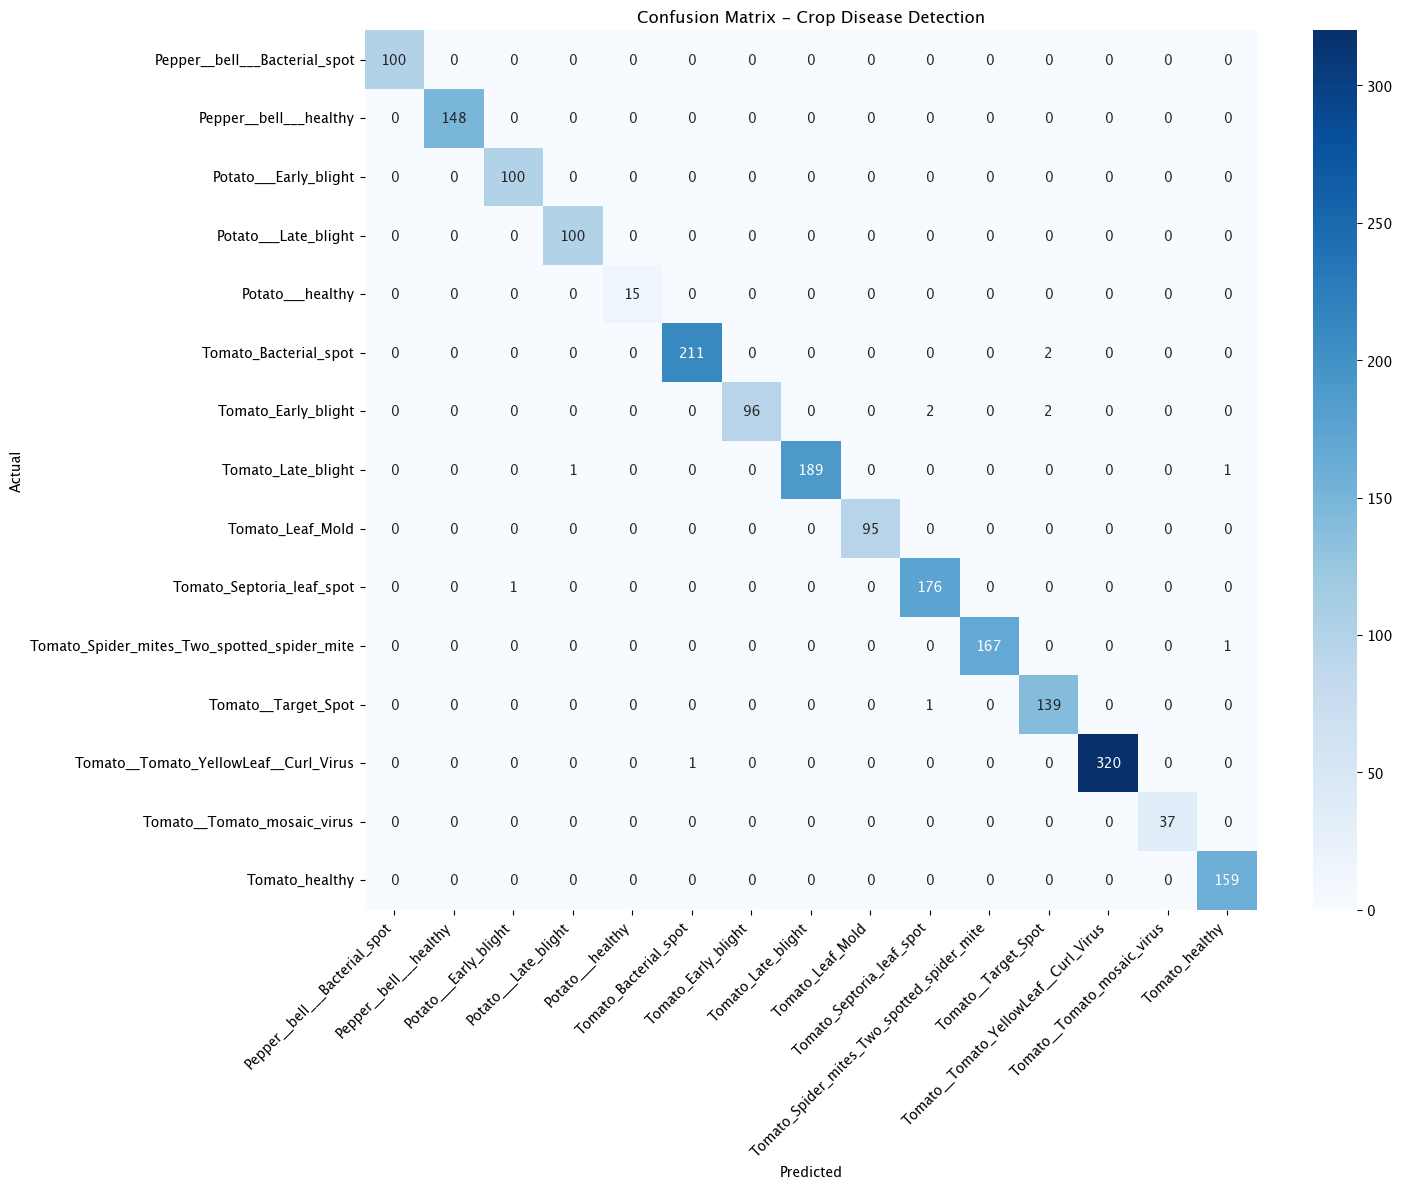

In [118]:
# 1. Confusion Matrix
plt.figure(figsize=(15, 12))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Crop Disease Detection')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [119]:
# 2. Classification Report
print("\n DETAILED CLASSIFICATION REPORT:")
print(classification_report(y_true, y_pred, target_names=class_names))


 DETAILED CLASSIFICATION REPORT:
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       1.00      1.00      1.00       100
                     Pepper__bell___healthy       1.00      1.00      1.00       148
                      Potato___Early_blight       0.99      1.00      1.00       100
                       Potato___Late_blight       0.99      1.00      1.00       100
                           Potato___healthy       1.00      1.00      1.00        15
                      Tomato_Bacterial_spot       1.00      0.99      0.99       213
                        Tomato_Early_blight       1.00      0.96      0.98       100
                         Tomato_Late_blight       1.00      0.99      0.99       191
                           Tomato_Leaf_Mold       1.00      1.00      1.00        95
                  Tomato_Septoria_leaf_spot       0.98      0.99      0.99       177
Tomato_Spider_mites_Two_spotte

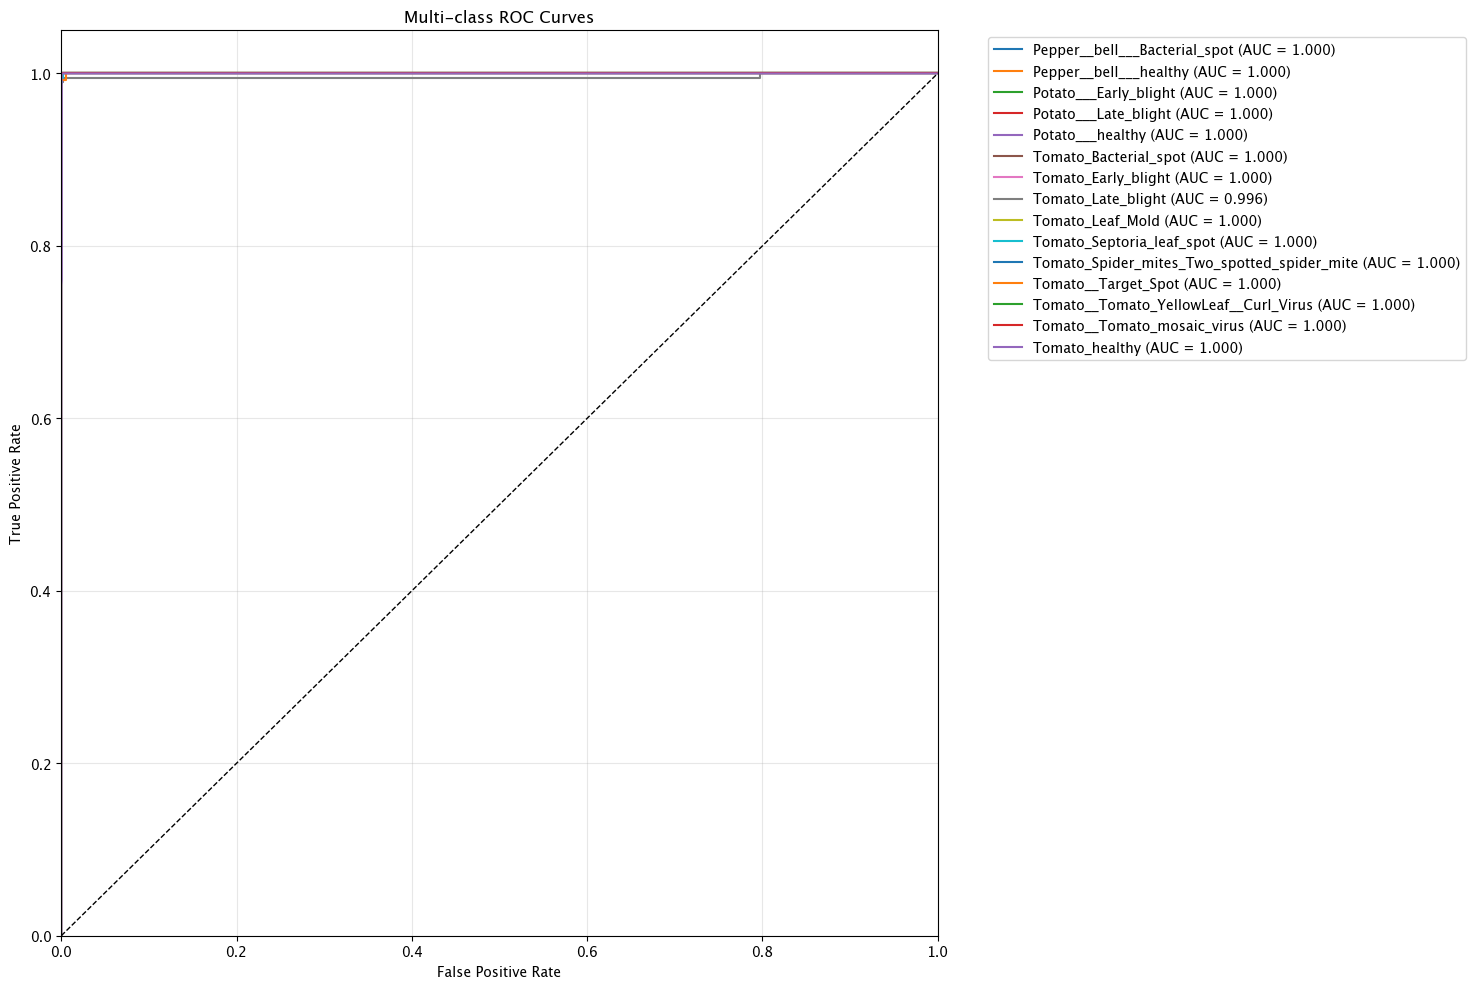

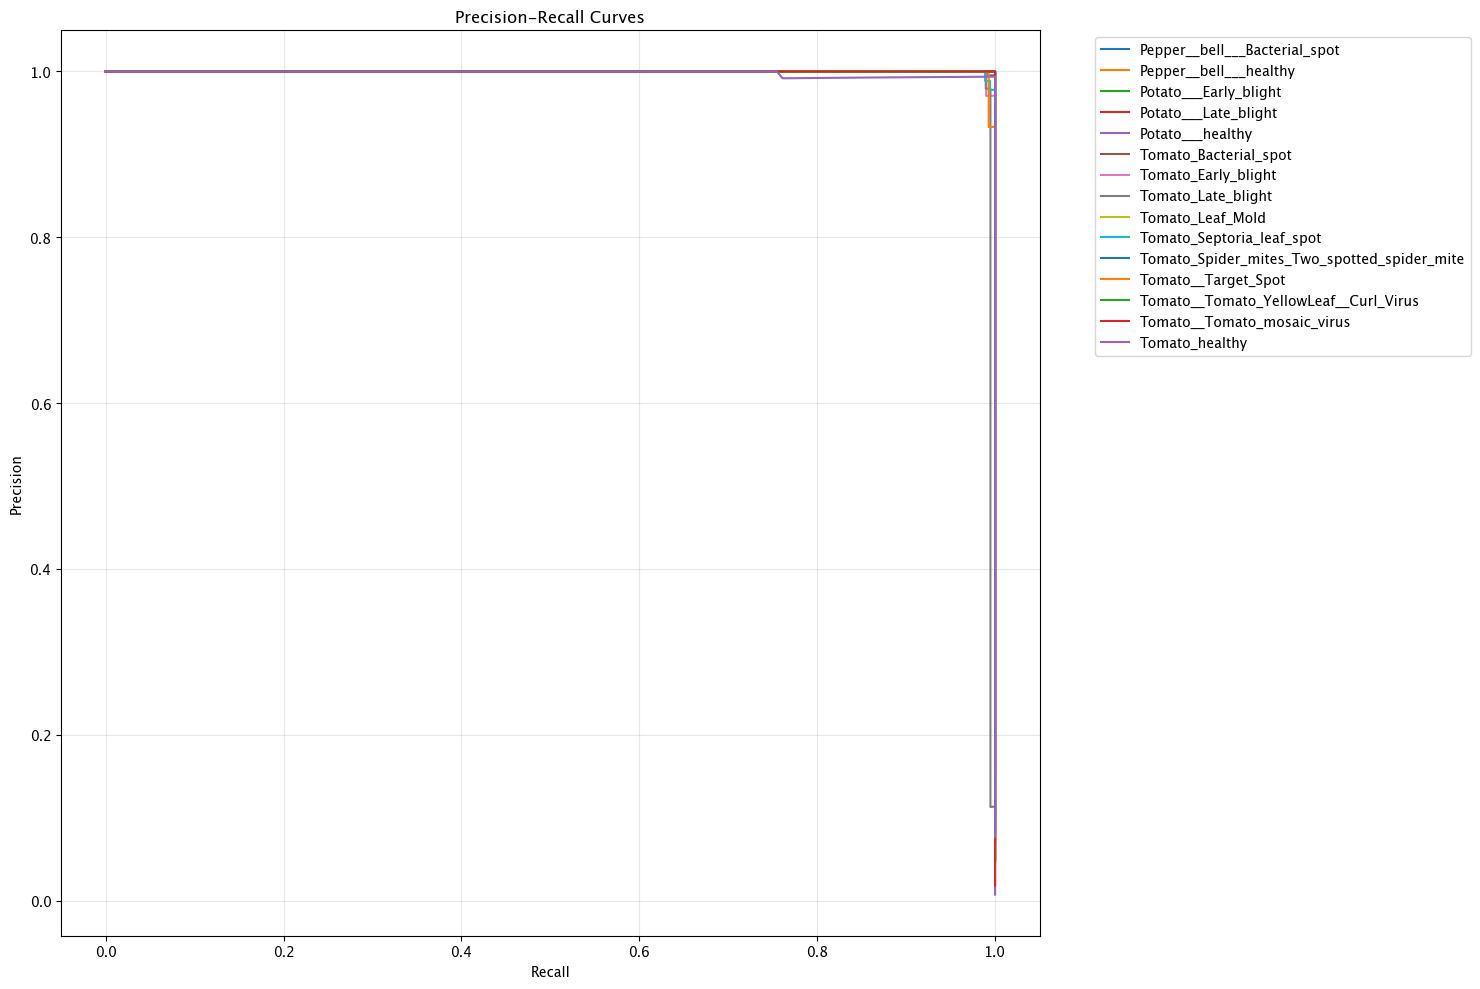

KeyError: 'lr'

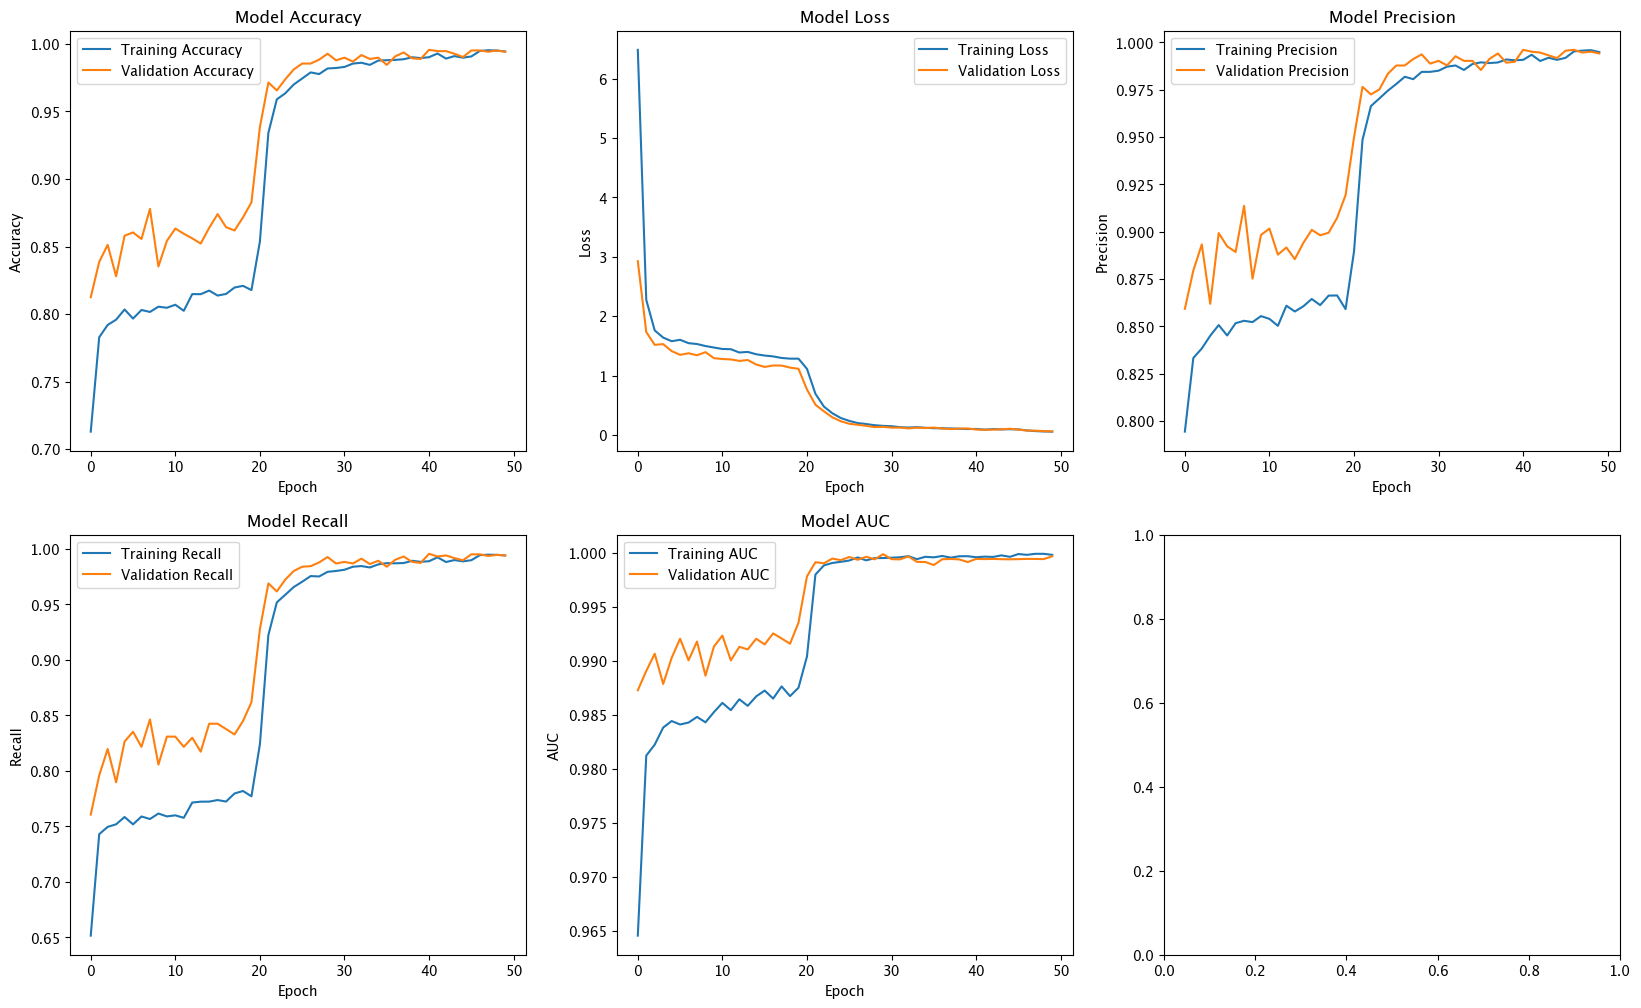

In [120]:
# 3. ROC Curve for each class
plt.figure(figsize=(15, 10))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true == i, y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curves')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# %%
# 4. Precision-Recall Curve
plt.figure(figsize=(15, 10))
for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(y_true == i, y_pred_proba[:, i])
    plt.plot(recall, precision, label=f'{class_names[i]}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# %%
# 5. Training History Visualization
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Accuracy
axes[0,0].plot(history['accuracy'], label='Training Accuracy')
axes[0,0].plot(history['val_accuracy'], label='Validation Accuracy')
axes[0,0].set_title('Model Accuracy')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Accuracy')
axes[0,0].legend()

# Loss
axes[0,1].plot(history['loss'], label='Training Loss')
axes[0,1].plot(history['val_loss'], label='Validation Loss')
axes[0,1].set_title('Model Loss')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Loss')
axes[0,1].legend()

# Precision
axes[0,2].plot(history['precision'], label='Training Precision')
axes[0,2].plot(history['val_precision'], label='Validation Precision')
axes[0,2].set_title('Model Precision')
axes[0,2].set_xlabel('Epoch')
axes[0,2].set_ylabel('Precision')
axes[0,2].legend()

# Recall
axes[1,0].plot(history['recall'], label='Training Recall')
axes[1,0].plot(history['val_recall'], label='Validation Recall')
axes[1,0].set_title('Model Recall')
axes[1,0].set_xlabel('Epoch')
axes[1,0].set_ylabel('Recall')
axes[1,0].legend()

# AUC
axes[1,1].plot(history['auc'], label='Training AUC')
axes[1,1].plot(history['val_auc'], label='Validation AUC')
axes[1,1].set_title('Model AUC')
axes[1,1].set_xlabel('Epoch')
axes[1,1].set_ylabel('AUC')
axes[1,1].legend()

# Learning Rate
axes[1,2].plot(history['lr'], label='Learning Rate')
axes[1,2].set_title('Learning Rate Schedule')
axes[1,2].set_xlabel('Epoch')
axes[1,2].set_ylabel('Learning Rate')
axes[1,2].set_yscale('log')
axes[1,2].legend()

plt.tight_layout()
plt.show()




In [134]:
class CropDiseasePredictor:
    def __init__(self, model_path, class_names, img_size=(224, 224)):
        self.model = tf.keras.models.load_model(model_path, compile=False)
        self.class_names = class_names
        self.img_size = img_size
        self.preprocess_fn = tf.keras.applications.efficientnet.preprocess_input
    
    def predict_single_image(self, image_path):
        img = tf.keras.preprocessing.image.load_img(image_path, target_size=self.img_size)
        img_array = tf.keras.preprocessing.image.img_to_array(img)
        img_array = tf.expand_dims(img_array, 0)
        img_array = self.preprocess_fn(img_array)

        predictions = self.model.predict(img_array, verbose=0)
        
        predicted_class_idx = np.argmax(predictions[0])
        predicted_class = self.class_names[predicted_class_idx]
        confidence = float(np.max(predictions[0]))

        top_3_indices = np.argsort(predictions[0])[-3:][::-1]
        top_3_predictions = [
            {
                'class': self.class_names[idx],
                'confidence': float(predictions[0][idx])
            }
            for idx in top_3_indices
        ]

        return {
            'predicted_class': predicted_class,
            'confidence': confidence,
            'all_predictions': top_3_predictions,
            'raw_probabilities': predictions[0].tolist()
        }
    
    def predict_batch(self, image_paths):
        results = []
        for image_path in image_paths:
            result = self.predict_single_image(image_path)
            result['image_path'] = image_path
            results.append(result)
        return results


predictor = CropDiseasePredictor('../models/crop_disease_model.h5', class_names)

prediction = predictor.predict_single_image(
    "../data/test/Potato___healthy/1f9870b3-899e-46fb-98c9-cfc2ce92895b___RS_HL 1816.JPG"
)
print(prediction)


Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/Users/sola/african_crop_detector-1/.venv/lib/python3.9/site-packages/IPython/core/interactiveshell.py", line 3550, in run_code
  File "/var/folders/6q/ftq30_v91zz5l7m16xgxd_280000gp/T/ipykernel_9936/571039845.py", line 47, in <module>
    prediction = predictor.predict_single_image(
  File "/var/folders/6q/ftq30_v91zz5l7m16xgxd_280000gp/T/ipykernel_9936/571039845.py", line 9, in predict_single_image
    img = tf.keras.preprocessing.image.load_img(image_path, target_size=self.img_size)
  File "/Users/sola/african_crop_detector-1/.venv/lib/python3.9/site-packages/keras/src/utils/image_utils.py", line 236, in load_img
    img = pil_image.open(io.BytesIO(f.read()))
  File "/Users/sola/african_crop_detector-1/.venv/lib/python3.9/site-packages/PIL/Image.py", line 3559, in open
    :param mode: Input mode.
  File "/Users/sola/african_crop_detector-1/.venv/lib/python3.9/site-packages/PIL/Image.py", line 3547, in _open_core
  File "/Users/sola/african

In [ ]:
class ModelRetrainer:
    def __init__(self, base_model_path, class_names, img_size=(224, 224)):
        self.base_model_path = base_model_path
        self.class_names = class_names
        self.img_size = img_size
        self.model = None
        
    def load_new_data(self, new_data_path):
        """Load new data for retraining"""
        print(" Loading new data for retraining...")
        
        new_dataset = tf.keras.preprocessing.image_dataset_from_directory(
            new_data_path,
            image_size=self.img_size,
            batch_size=32,
            label_mode='categorical'
        )
        
        # Preprocess the new data
        new_dataset = new_dataset.map(
            lambda x, y: (tf.keras.applications.efficientnet.preprocess_input(x), y)
        )
        
        new_dataset = new_dataset.prefetch(tf.data.AUTOTUNE)
        
        print(f" Loaded {len(new_dataset) * 32} new samples")
        return new_dataset
    
    def retrain_model(self, new_data_path, epochs=10):
        """Retrain model with new data"""
        print("🔄 Starting model retraining...")
        
        # Load current model
        self.model = tf.keras.models.load_model(self.base_model_path)
        
        # Load new data
        new_dataset = self.load_new_data(new_data_path)
        
        # Fine-tune with lower learning rate
        self.model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
            loss='categorical_crossentropy',
            metrics=['accuracy', 'precision', 'recall', 'auc']
        )
        
        # Retrain with callbacks
        retrain_callbacks = [
            tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
            tf.keras.callbacks.ReduceLROnPlateau(patience=3)
        ]
        
        retrain_history = self.model.fit(
            new_dataset,
            epochs=epochs,
            callbacks=retrain_callbacks,
            verbose=1
        )
        
        # Save retrained model
        retrained_path = '../models/retrained_model.h5'
        self.model.save(retrained_path)
        
        print(f" Model retraining completed! Saved to {retrained_path}")
        return retrain_history, retrained_path


# retrain_history, new_model_path = retrainer.retrain_model('../data/uploaded/new_training_data')

print(" Retraining pipeline ready!")



 Retraining pipeline ready!


In [123]:
# Feature interpretation through Grad-CAM
def get_grad_cam_heatmap(model, img_array, layer_name='top_conv'):
    """Generate Grad-CAM heatmap for feature interpretation"""
    grad_model = tf.keras.models.Model(
        [model.inputs], 
        [model.get_layer(layer_name).output, model.output]
    )
    
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, np.argmax(predictions[0])]
    
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_mean(tf.multiply(conv_outputs, pooled_grads), axis=-1)
    heatmap = np.maximum(heatmap, 0) / np.max(heatmap)
    
    return heatmap

In [124]:
# Save model and configuration for deployment
deployment_config = {
    'class_names': class_names,
    'img_size': IMG_SIZE,
    'model_path': '../models/crop_disease_model.h5',
    'evaluation_metrics': {
        'accuracy': float(test_accuracy),
        'precision': float(test_precision),
        'recall': float(test_recall),
        'f1_score': float(test_f1),
        'auc': float(test_auc)
    }
}

with open('../models/deployment_config.json', 'w') as f:
    json.dump(deployment_config, f, indent=2)

print("\n COMPLETE ML PIPELINE EXECUTED SUCCESSFULLY!")

print("="*60)


 COMPLETE ML PIPELINE EXECUTED SUCCESSFULLY!
